# SECP3223 Group Project - Phase I: Data Preparation and Cleaning

**Course**: Data Analytics Programming  
**Semester**: 2024/2025 Semester 2    

**Group Members**:  
- Joanne Ching Yin Xuan (A23CS0227)  
- Lee Yin Shen (A23CS0236)  
- Lim Yu Han (A23CS0241)  
- Tan Zhi Ming (A23CS0189)    

# PHASE 1 : DATA PREPARATION AND CLEANING

## ii Do appropriate data cleaning, preparation and wrangling. 

### 1. Import libraries

In [108]:
# Import libraries
# pandas (pd) = for handling table-like data.
# numpy (np) = for doing math and working with arrays.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix


### 2. Load the Datasets

In [109]:
# Load fuel data into DataFrame
fuel_df = pd.read_csv("FuelConsumption.csv")

# Load cars 2025 data into DataFrame
cars_df = pd.read_csv("cars_2025.csv")


### 3. Preview Data

In [110]:
# Show first 5 rows of fuel data
print("Fuel Dataset:")
display(fuel_df.head())

print()  

# Show first 5 rows of cars 2025 data
print("Cars 2025 Dataset:")
display(cars_df.head())


Fuel Dataset:


,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244



Cars 2025 Dataset:


,date_reg,type,maker,model,colour,fuel,state
0,2025-01-01,motokar,BYD,Seal,white,electric,Rakan Niaga
1,2025-01-01,window_van,Cam,Placer-X,yellow,greendiesel,Johor
2,2025-01-01,jip,Chery,Jaecoo J7,green,petrol,Rakan Niaga
3,2025-01-01,jip,Chery,Jaecoo J7,silver,petrol,Rakan Niaga
4,2025-01-01,jip,Chery,Tiggo,grey,petrol,Rakan Niaga


### 4. Clean and Standardize Data

In [111]:
# Convert both content in MAKE and MODEL column to upper case for fuel dataset.
fuel_df['MAKE'] = fuel_df['MAKE'].str.upper().str.strip()
fuel_df['MODEL'] = fuel_df['MODEL'].str.upper().str.strip()

# Convert both content in maker and model column to upper case for car dataset.
cars_df['maker'] = cars_df['maker'].str.upper().str.strip()
cars_df['model'] = cars_df['model'].str.upper().str.strip()

# Convert the 'type' and 'fuel' column name to uppercase for car dataset.
cars_df.rename(columns={'type': 'TYPE', 'fuel': 'FUEL'}, inplace=True)

# Convert both content in TYPE and FUEL column to upper case for car dataset.
cars_df['TYPE'] = cars_df['TYPE'].str.upper().str.strip()
cars_df['FUEL'] = cars_df['FUEL'].str.upper().str.strip()

### 5. Drop Duplicates and Missing Values

In [112]:
# Drop Duplicates and Missing Values
fuel_df.drop_duplicates(inplace=True)
cars_df.drop_duplicates(inplace=True)

fuel_df.dropna(inplace=True)
cars_df.dropna(inplace=True)

### 6. Drop Unused coloumn

In [113]:
# Drop unused columns from fuel dataset
fuel_df = fuel_df.drop(columns=['MODELYEAR', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB_MPG'])

# Drop unused columns from cars dataset
cars_df = cars_df.drop(columns=['date_reg', 'colour', 'state'])

### 7. Encode Data

In [118]:
# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# Encode the 'TRANSMISSION' column in the merged dataset
fuel_df['TRANSMISSION'] = label_encoder.fit_transform(fuel_df['TRANSMISSION'])

# Display the first few rows to verify the encoding
display(fuel_df.head())


,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,ACURA,ILX,COMPACT,2.0,4,10,Z,8.5,196
1,ACURA,ILX,COMPACT,2.4,4,20,Z,9.6,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,17,Z,5.9,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,11,Z,11.1,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,11,Z,10.6,244


### 8. Merge both datasets

In [119]:
# Combine car_df and fuel_df where maker and model are the same
# Keep only rows that match in both tables
merged_df = pd.merge(
    cars_df,
    fuel_df,
    left_on=['maker', 'model'],
    right_on=['MAKE', 'MODEL'],
    how='inner'
)

# Preview merged data
display(merged_df.head())

# Drop 'maker' and 'model' columns and keep 'MAKE' and 'MODEL' to reduce redundancy
final_data_cleaned = merged_df.drop(columns=['maker', 'model'])

# Preview the data after dropping redundant columns
display(final_data_cleaned.head())


,TYPE,maker,model,FUEL,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,MOTOKAR,PORSCHE,911 CARRERA,PETROL,PORSCHE,911 CARRERA,MINICOMPACT,3.4,6,8,Z,10.1,232
1,MOTOKAR,PORSCHE,911 CARRERA,PETROL,PORSCHE,911 CARRERA,MINICOMPACT,3.4,6,21,Z,10.7,246
2,MOTOKAR,HONDA,CIVIC,PETROL,HONDA,CIVIC,COMPACT,1.8,4,15,X,7.0,161
3,MOTOKAR,HONDA,CIVIC,PETROL,HONDA,CIVIC,COMPACT,1.8,4,17,X,7.2,166
4,MOTOKAR,HONDA,CIVIC,PETROL,HONDA,CIVIC,COMPACT,1.8,4,19,X,7.6,175


,TYPE,FUEL,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,MOTOKAR,PETROL,PORSCHE,911 CARRERA,MINICOMPACT,3.4,6,8,Z,10.1,232
1,MOTOKAR,PETROL,PORSCHE,911 CARRERA,MINICOMPACT,3.4,6,21,Z,10.7,246
2,MOTOKAR,PETROL,HONDA,CIVIC,COMPACT,1.8,4,15,X,7.0,161
3,MOTOKAR,PETROL,HONDA,CIVIC,COMPACT,1.8,4,17,X,7.2,166
4,MOTOKAR,PETROL,HONDA,CIVIC,COMPACT,1.8,4,19,X,7.6,175


### Last. Save cleaned data to CSV 

In [120]:
# Save the dataframe as a tab-separated file
final_data_cleaned.to_csv("cleaned_merged_car_data_2.csv", index=False)


### iii. Do appropriate data aggregation and group operations.

#### 1. Average Carbon Emissions by Car Maker

1. Average Carbon Emissions by Car Maker

            MAKE  CO2EMISSIONS
0   ASTON MARTIN    359.000000
1        BENTLEY    348.600000
2       MASERATI    347.000000
3         NISSAN    297.000000
4        PORSCHE    281.244635
5          DODGE    279.500000
6           AUDI    272.281250
7           FORD    266.568627
8          VOLVO    257.320388
9     VOLKSWAGEN    255.923963
10       HYUNDAI    249.205128
11           KIA    245.193548
12        JAGUAR    242.000000
13          JEEP    230.000000
14    LAND ROVER    225.000000
15     CHEVROLET    213.833333
16        SUBARU    208.500000
17         MAZDA    196.610419
18    MITSUBISHI    190.000000
19         HONDA    178.536755
20        TOYOTA    174.318476

- The Top 10 Car Makers by Average CO2 Emissions


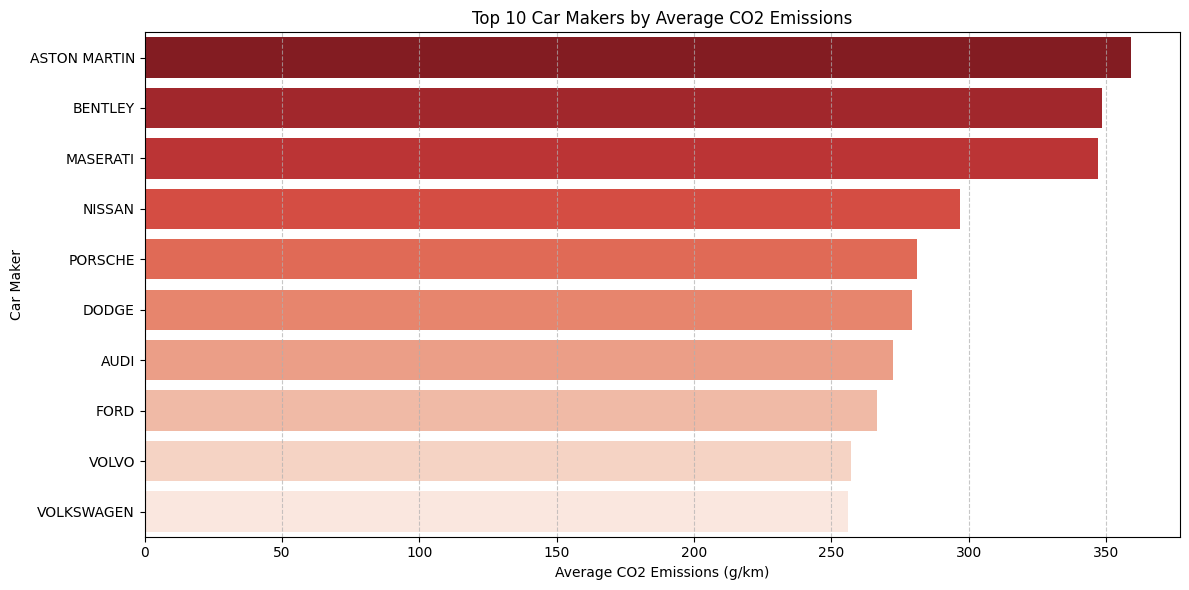

In [121]:
# Group by Car Maker and calculate the average CO2 emissions
avg_emissions_by_maker = final_data_cleaned.groupby('MAKE')['CO2EMISSIONS'].mean().reset_index()
avg_emissions_by_maker.sort_values('CO2EMISSIONS', ascending=False, inplace=True)
avg_emissions_by_maker.reset_index(drop=True, inplace=True)

# Display the result in table
print('1. Average Carbon Emissions by Car Maker\n')
print(avg_emissions_by_maker)
print()

# Display the result in chart
print('- The Top 10 Car Makers by Average CO2 Emissions')
plt.figure(figsize=(12,6))
sns.barplot(data=avg_emissions_by_maker.head(10), x='CO2EMISSIONS', y='MAKE', hue='MAKE', palette='Reds_r')
plt.title('Top 10 Car Makers by Average CO2 Emissions')
plt.xlabel('Average CO2 Emissions (g/km)')
plt.ylabel('Car Maker')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)  # Add grid lines along x-axis
plt.tight_layout()
plt.show()


#### 2. Average Carbon Emissions by Car Model

2. Average Carbon Emissions by Car Model

                 MODEL  CO2EMISSIONS
0             MULSANNE    437.000000
1                   R8    376.500000
2             VANQUISH    359.000000
3          GRANTURISMO    347.000000
4       CONTINENTAL GT    326.500000
5              911 GT3    322.000000
6                   Q7    304.000000
7                 GT-R    297.000000
8                   S8    297.000000
9              CAYENNE    294.500000
10                 SQ5    292.000000
11                 RS7    290.000000
12                CX-9    283.000000
13             TOUAREG    281.000000
14          CHALLENGER    279.500000
15           911 TURBO    274.000000
16             MUSTANG    267.800000
17            CORVETTE    267.000000
18              SIENNA    260.000000
19                  A8    259.000000
20                XC60    258.000000
21            SANTA FE    258.000000
22              TIGUAN    256.500000
23            PANAMERA    251.000000
24             SORENTO    249.500

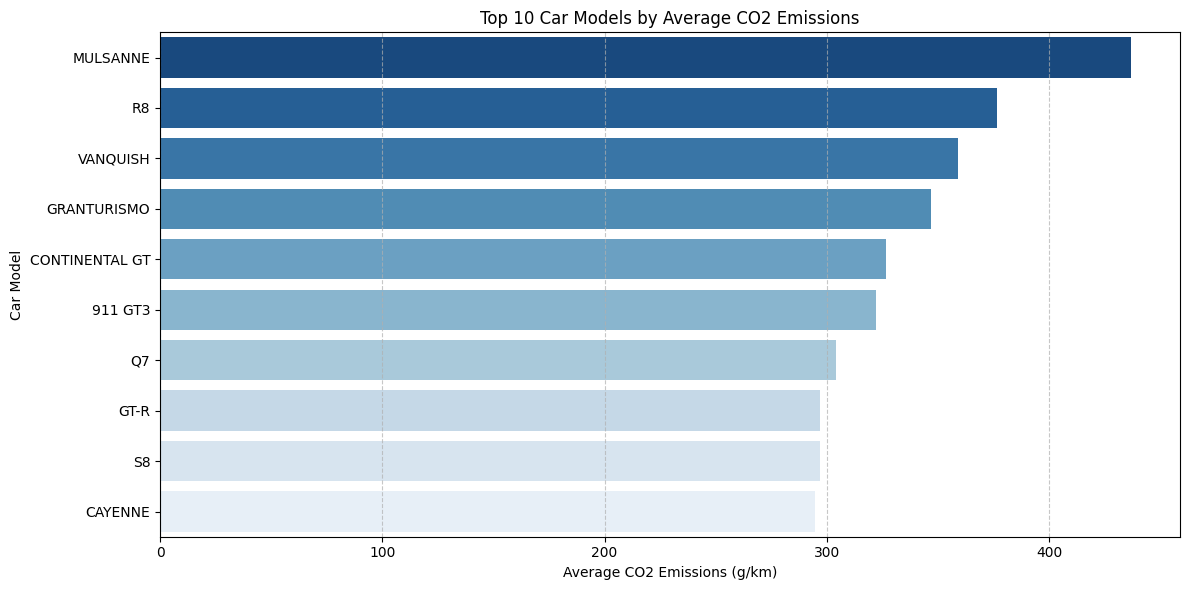

In [122]:
# Group by Car Model and calculate the average CO2 emissions
avg_emissions_by_model = final_data_cleaned.groupby('MODEL')['CO2EMISSIONS'].mean().reset_index()
avg_emissions_by_model.sort_values('CO2EMISSIONS', ascending=False, inplace=True)
avg_emissions_by_model.reset_index(drop=True, inplace=True)

# Display the result in table
print('2. Average Carbon Emissions by Car Model\n')
print(avg_emissions_by_model)
print()

# Display the result in chart
print('- The Top 10 Car Models by Average CO2 Emissions')
plt.figure(figsize=(12,6))
sns.barplot(data=avg_emissions_by_model.head(10), x='CO2EMISSIONS', y='MODEL', hue='MODEL', palette='Blues_r')
plt.title('Top 10 Car Models by Average CO2 Emissions')
plt.xlabel('Average CO2 Emissions (g/km)')
plt.ylabel('Car Model')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)  # Adds vertical grid lines
plt.tight_layout()
plt.show()


#### 3. Average Emissions by Engine Size

4. Average Emissions by Engine Size

  Engine_Size  CO2EMISSIONS
0       >4.0L    304.581395
1    2.5–3.0L    270.285714
2    3.0–4.0L    267.535440
3    2.0–2.5L    208.138904
4    1.5–2.0L    182.605289
5       <1.5L    165.725451

- The Average CO2 Emmissions by Engine Size


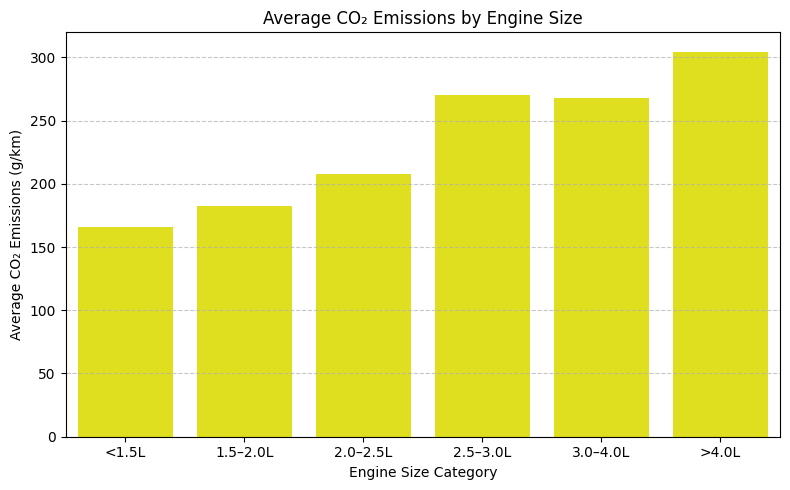

In [123]:
# Group by Engine Size Class and calculate the average CO2 emissions
bins = [0, 1.5, 2.0, 2.5, 3.0, 4.0, 10]
labels = ['<1.5L', '1.5–2.0L', '2.0–2.5L', '2.5–3.0L', '3.0–4.0L', '>4.0L']

final_data_cleaned['Engine_Size'] = pd.cut(final_data_cleaned['ENGINESIZE'], bins=bins, labels=labels)
avg_emissions_by_engine_size = final_data_cleaned.groupby('Engine_Size', observed=False)['CO2EMISSIONS'].mean().reset_index()
avg_emissions_by_engine_size.sort_values('CO2EMISSIONS', ascending=False, inplace=True)
avg_emissions_by_engine_size.reset_index(drop=True, inplace=True)

# Display the result in table
print('4. Average Emissions by Engine Size\n')
print(avg_emissions_by_engine_size)
print()

# Display the result in chart
print('- The Average CO2 Emmissions by Engine Size')
plt.figure(figsize=(8,5))
sns.barplot(data=avg_emissions_by_engine_size, x='Engine_Size', y='CO2EMISSIONS', color='yellow') 
plt.title('Average CO₂ Emissions by Engine Size')
plt.xlabel('Engine Size Category')
plt.ylabel('Average CO₂ Emissions (g/km)')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)  
plt.tight_layout()
plt.show()


#### 4. Average Emissions by Vehicle Class

5. Average Emissions by Vehicle Class

            VEHICLECLASS  CO2EMISSIONS
0         SUV - STANDARD    294.241779
1             SUBCOMPACT    282.318182
2              FULL-SIZE    251.000000
3                MINIVAN    244.186047
4             TWO-SEATER    234.000000
5            MINICOMPACT    232.012658
6            SUV - SMALL    211.414494
7               MID-SIZE    197.086854
8  STATION WAGON - SMALL    174.500000
9                COMPACT    167.140147



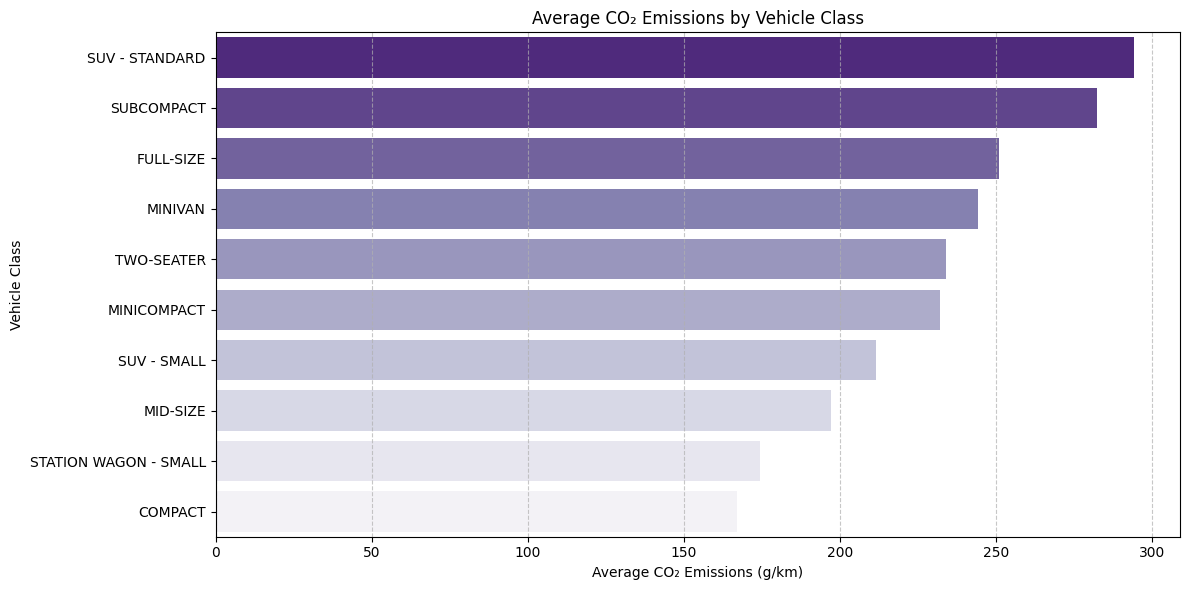

In [124]:
# Group by Vehicle Class and calculate the average CO2 emissions
avg_emissions_by_class = final_data_cleaned.groupby('VEHICLECLASS')['CO2EMISSIONS'].mean().reset_index()
avg_emissions_by_class.sort_values('CO2EMISSIONS', ascending=False, inplace=True)
avg_emissions_by_class.reset_index(drop=True, inplace=True)

# Display the result in table
print('5. Average Emissions by Vehicle Class\n')
print(avg_emissions_by_class)
print()

# Display the result in chart
plt.figure(figsize=(12,6))
sns.barplot(data=avg_emissions_by_class, x='CO2EMISSIONS', y='VEHICLECLASS', palette='Purples_r', hue='VEHICLECLASS')
plt.title('Average CO₂ Emissions by Vehicle Class')
plt.xlabel('Average CO₂ Emissions (g/km)')
plt.ylabel('Vehicle Class')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)  # Adds vertical grid lines
plt.tight_layout()
plt.show()





#### 5. Average Emissions by Transmission Type

6. Average Emissions by Transmission Type

    TRANSMISSION  CO2EMISSIONS
0              3    345.000000
1              7    297.000000
2             13    276.363636
3              4    276.000000
4              8    248.388430
5             21    246.155844
6              2    243.420619
7             20    236.402733
8              5    230.000000
9             14    225.000000
10             1    208.695866
11            11    203.147541
12            18    202.000000
13            16    189.000000
14            19    174.237298
15             0    168.522244
16            17    166.054446
17            15    161.054446


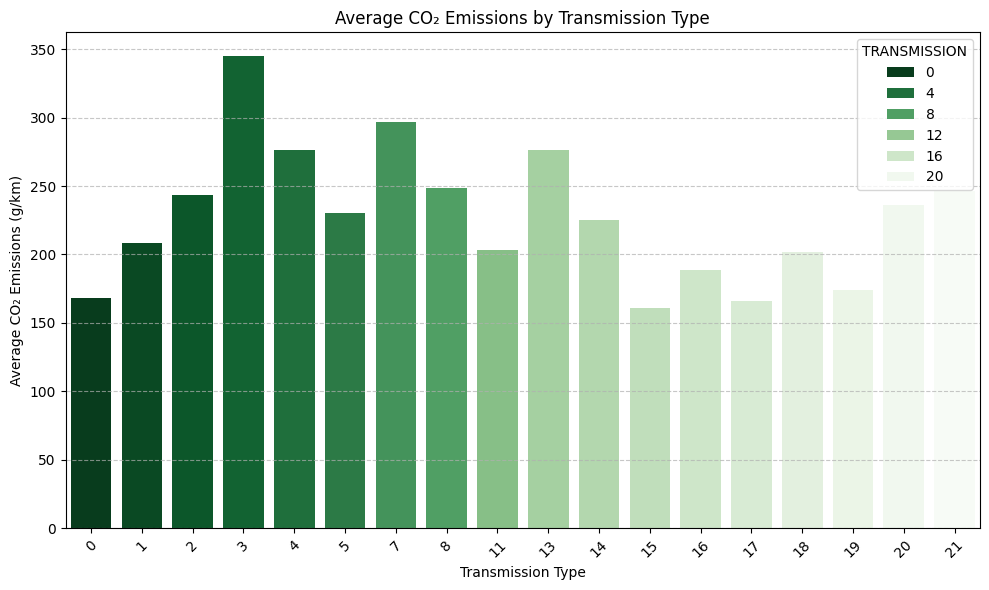

In [125]:
# Group by Transmission Type and calculate the average CO2 emissions
avg_emissions_by_transmission = final_data_cleaned.groupby('TRANSMISSION')['CO2EMISSIONS'].mean().reset_index()
avg_emissions_by_transmission.sort_values('CO2EMISSIONS', ascending=False, inplace=True)
avg_emissions_by_transmission.reset_index(drop=True, inplace=True)

# Display the result in table
print('6. Average Emissions by Transmission Type\n')
print(avg_emissions_by_transmission)

# Display the result in chart
plt.figure(figsize=(10,6))
sns.barplot(data=avg_emissions_by_transmission, x='TRANSMISSION', y='CO2EMISSIONS', palette='Greens_r', hue='TRANSMISSION')
plt.title('Average CO₂ Emissions by Transmission Type')
plt.xlabel('Transmission Type')
plt.ylabel('Average CO₂ Emissions (g/km)')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust the plot layout to avoid clipping
plt.grid(True, axis='y', linestyle='--', alpha=0.7)  # Adds grid lines on y-axis
plt.show()


# PHASE 2: DATA ANALYTICS, VISUALIZATION 
### i. Perform summary analytics to highlight important information from the prepared dataset. 



*1. Average Carbon Emissions by Car Maker* <br>
High-performance and luxury automobile manufacturers, such Aston Martin (359.0 g/km), Bently (348.6 g/km), and Maserati (347.0 g/km), routinely produce cars with higher average emissions, according to an analysis of average carbon dioxide (CO2) emissions by automaker.  These manufacturers are renowned for creating automobiles with strong engines and plenty of horsepower, which usually mean that they use more fuel and emit more pollution.  Conversely, automakers that prioritize hybrid and economy cars, like Honda and Toyota, often have far lower average emissions, with Honda coming in at 178.5 g/km and Toyota at 174.3 g/km.  This research demonstrates the important influence that car design philosophy and brand strategy have on environmental performance. Power and luxury-focused automakers frequently forgo fuel economy, which increases greenhouse gas emissions.  This further supports the necessity for emission standards aimed at high-emission sectors of the industry and sustainable vehicle design.

*2. Average Carbon Emissions by Car Model* <br>
Luxury and high-performance cars typically have the highest average CO2 emissions when broken down by model.  The greatest emissions, for instance, are found in the Bentley Mulsanne (437.0 g/km), Audi R8 (376.5 g/km), and Aston Martin Vanquish (359.0 g/km).  Performance is the primary focus of these cars, frequently at the expense of fuel economy.  In contrast, vehicles with more fuel-efficient designs, such as the Toyota Corolla (169.5 g/km) and Honda Civic (167.3 g/km), emit far fewer emissions. This model-level understanding is critical for consumers and policymakers alike.  It demonstrates that emissions can vary dramatically even within the same brand based on model type and engine characteristics. To be effective, emissions reduction initiatives must target particular high-emission models as well as brands as a whole.

*3. Average Carbon Emissions by Engine Size* <br>
The relationship between engine size and CO2 emissions is clear: larger engines use more fuel per cycle, resulting in higher emissions. Vehicles with engine sizes over 4.0L have the greatest average emissions at 304.58 g/km, while those with engine sizes under 1.5L have the lowest emissions at 165.73 g/km.  Intermediate engine sizes, such as 2.5-3.0L and 3.0-4.0L, produce higher emissions, averaging 270.29 g/km and 267.54 g/km, respectively. This link is consistent across numerous fuel types, confirming that engine size is a significant determinant of emission levels.  This information is very useful for both customers making purchasing decisions and government agencies developing automobile taxation policies or emission limitations.  Incentives for smaller engine vehicles or downsizing technology such as turbocharging might drastically cut fleet-wide emissions.

*4. Average Carbon Emissions by Vehicle Class* <br>
The vehicle class has a considerable impact on emissions, with larger cars often releasing more CO2.  SUVs (Standard) have the greatest average emissions, 294.24 g/km, due to their greater size and more powerful engines.  Similarly, subcompact vehicles have comparatively high emissions of 282.32 g/km, although smaller vehicle classes, such as compact and station wagons, have lower emissions of 167.14 g/km and 174.5 g/km. This supports the claim that vehicle size and mass are closely related to carbon production.  In nations like Malaysia, where car ownership is increasing and urban congestion is increasing, promoting smaller and more efficient vehicle classes could be an effective strategy for decreasing urban pollution and reaching environmental targets.

*5. Average Emissions by Transmission Type* <br>
Transmission type is another aspect that affects car emissions.  According to the analysis, automatic transmissions (e.g., A7, AM6) emit more CO2 than manual transmissions.  The highest emissions are seen in cars with A7 (automatic, 7 gears), which emit an average of 345.0 g/km.  In comparison, automobiles with manual transmissions, such as the M5, produce much lower emissions, averaging 174.24 g/km.  Automatic transmissions, typically found in larger or performance-oriented vehicles, are associated with higher emissions due to inefficient fuel usage. Manual transmissions, on the other hand, are more common in smaller cars, which are more fuel-efficient and produce fewer emissions.

### ii. Perform appropriate machine learning method to classify / cluster the car maker / car model according to their carbon emissions using machine learning

In this analysis, we will classify cars into their car makers using features like CO2 emissions, engine size, fuel consumption, cylinders, and transmission type. To do this, we'll use the Random Forest algorithm, a machine learning technique that combines several decision trees for better accuracy. We will split the data into 80% for training and 20% for testing. By training the model with these features, we'll predict the car maker and assess the model's performance using accuracy and the confusion matrix to see how well it performs and which features are most important.

Accuracy of Car Maker Classification: 99.62%


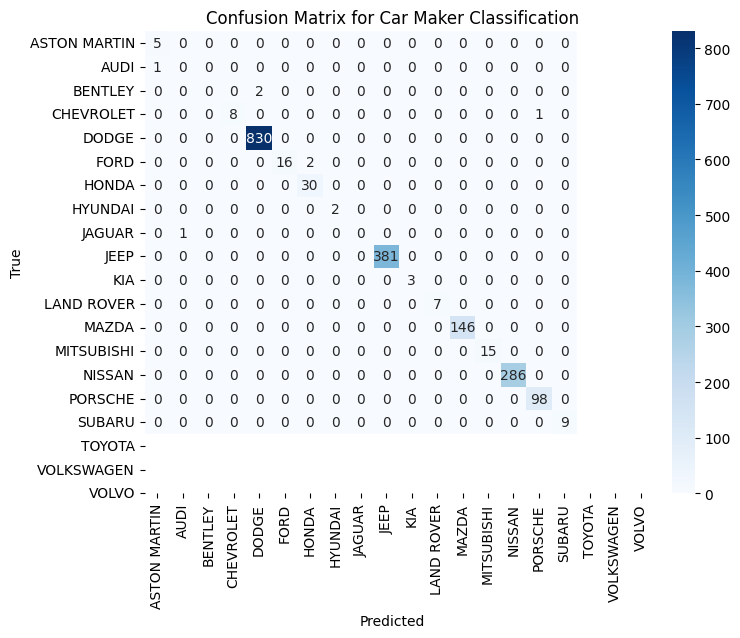

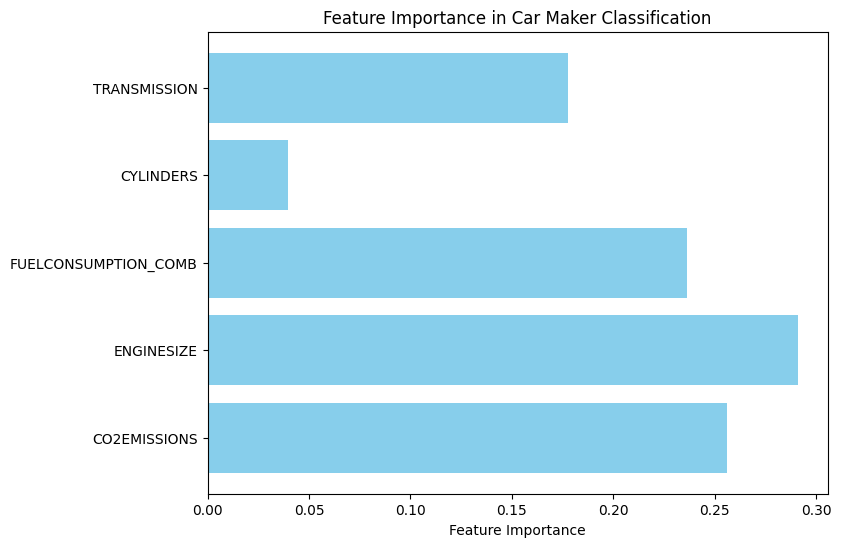

In [129]:
# Select features (CO2 emissions, engine size, fuel consumption, cylinders, and transmission) for classification
X = final_data_cleaned[['CO2EMISSIONS', 'ENGINESIZE', 'FUELCONSUMPTION_COMB', 'CYLINDERS', 'TRANSMISSION']]  # Features (input variables)
y = final_data_cleaned['MAKE']  # Target variable (car maker)

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the classifier
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Evaluate the classifier's accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of Car Maker Classification: {accuracy * 100:.2f}%")

# Confusion matrix to see detailed performance
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=rf_classifier.classes_, yticklabels=rf_classifier.classes_)
plt.title('Confusion Matrix for Car Maker Classification')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Feature importance: To see which features are important for classification
feature_importances = rf_classifier.feature_importances_
features = ['CO2EMISSIONS', 'ENGINESIZE', 'FUELCONSUMPTION_COMB', 'CYLINDERS', 'TRANSMISSION']

# Plot feature importance
plt.figure(figsize=(8, 6))
plt.barh(features, feature_importances, color='skyblue')
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Car Maker Classification')
plt.show()


The first figure shows the confusion matrix, which illustrates how well the Random Forest classifier predicted the car makers based on the selected features. The diagonal elements represent the correct predictions, where the true and predicted labels match. For example, Dodge has 830 correct predictions, Hyundai has 381, Mazda had 146, and Nissan has 286. The off-diagonal elements show misclassifications, such as Audi being misclassified as ASTON MARTIN (1 time), Jaguar as Audi (1 time), Ford as Honda (2 times), and Chevrolet as Porsche (1 time). Even though got these errors, the model achieves a high accuracy of 99.62%, indicating strong performance overall for this dataset.

The second figure shows the feature importance, helping us understand which features were most influential in predicting the car maker. Engine Size had the highest importance, followed by CO2 Emissions and Fuel Consumption. These three features are crucial for the classification task, with Engine Size being the most significant. On the other hand, Transmission contributed less, and Cylinders had the smallest impact, making it the least important feature. In summary, Engine Size, CO2 Emissions, and Fuel Consumption were key drivers of the model's predictions, while Transmission and Cylinders played a smaller role.